# Xây dựng mô hình Logistic Regression cho bài toán Titanic

## 1. Tải và đọc dữ liệu

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

dataset_path = "./data/titanic_modified_dataset.csv"
df = pd.read_csv(dataset_path, index_col="PassengerId")
df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Survived
PassengerId,,,,,,,,,
1,3,0,22.0,1,0,7.2500,0,0,0
2,1,1,38.0,1,0,71.2833,1,1,1
3,3,1,26.0,0,0,7.9250,0,2,1
4,1,1,35.0,1,0,53.1000,0,1,1
5,3,0,35.0,0,0,8.0500,0,0,0


## 2. Khám phá dữ liệu

In [90]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    int64  
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    int64  
 7   Title     891 non-null    int64  
 8   Survived  891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 69.6 KB


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,Survived
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,2.308642,0.352413,29.361582,0.523008,0.381594,32.204208,0.359147,0.936027,0.383838
std,0.836071,0.477990,13.019697,1.102743,0.806057,49.693429,0.638707,1.725341,0.486592
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000
25%,2.000000,0.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000,0.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,0.000000,0.000000,0.000000
75%,3.000000,1.000000,35.000000,1.000000,0.000000,31.000000,1.000000,2.000000,1.000000
max,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000,16.000000,1.000000


## 3. Tách X, y và thêm cột bias

In [91]:
dataset_arr = df.to_numpy().astype(np.float64)
X, y = dataset_arr[:, :-1], dataset_arr[:, -1]

print(X.shape)

(891, 8)


In [92]:
intercept = np.ones((X.shape[0], 1))
X_b = np.concatenate((intercept, X), axis=1)

## 4. Chia tập train, validation và test

In [93]:
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X_b, y, test_size=val_size,
    random_state=random_state, shuffle=is_shuffle
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train, test_size=test_size,
    random_state=random_state, shuffle=is_shuffle
)

## 5. Chuẩn hóa đặc trưng

In [94]:
normalizer = StandardScaler()

X_train[:, 1:] = normalizer.fit_transform(X_train[:, 1:])
X_val[:, 1:] = normalizer.transform(X_val[:, 1:])
X_test[:, 1:] = normalizer.transform(X_test[:, 1:])

## 6. Huấn luyện mô hình

In [95]:
def sigmoid(z):
    result = 1 / (1 + np.exp(-z))
    return result

def predict(X, theta):
    dot_product = X.dot(theta)
    y_hat = sigmoid(dot_product)
    return y_hat

Hàm `np.clip` chặn `y_hat` trong khoảng [1e-7, 1 - 1e-7]. Khi mô hình dự đoán quá tự tin và `y_hat` chạm vào đúng 0 hoặc 1 thì log(0) cho ra vô cực và loss trở thành `nan`

In [96]:
def compute_loss(y_hat, y):
    y_hat = np.clip(y_hat, 1e-7, 1 - 1e-7)

    return - np.mean(y * np.log(y_hat) + (1-y) * np.log(1-y_hat))

In [97]:
def compute_gradient(X, y, y_hat):
    m = X.shape[0]
    return X.T.dot(y_hat - y) / m

def update_theta(theta, gradient, lr):
    return theta - lr * gradient

In [98]:
def compute_accuracy(X, y, theta):
    m = X.shape[0]
    y_hat = predict(X, theta)
    y_hat = np.where(y_hat >= 0.5, 1, 0)
    acc = np.mean(y_hat == y)
    return acc

In [99]:
lr = 0.01
epochs = 100
batch_size = 16

np.random.seed(random_state)
theta = np.random.uniform(size=X_train.shape[1])

In [100]:
train_accs, train_losses = [], []
val_accs, val_losses = [], []

for epoch in range(epochs):
    train_batch_losses, train_batch_accs = [], []
    val_batch_losses, val_batch_accs = [], []

    for i in range(0, X_train.shape[0], batch_size):
        X_i = X_train[i:i+batch_size]
        y_i = y_train[i:i+batch_size]

        y_hat = predict(X_i, theta)
        train_loss = compute_loss(y_hat, y_i)
        gradient = compute_gradient(X_i, y_i, y_hat)
        theta = update_theta(theta, gradient, lr)

        train_batch_losses.append(train_loss)
        train_batch_accs.append(compute_accuracy(X_train, y_train, theta))

        y_val_hat = predict(X_val, theta)
        val_batch_losses.append(compute_loss(y_val_hat, y_val))
        val_batch_accs.append(compute_accuracy(X_val, y_val, theta))

    train_losses.append(sum(train_batch_losses) / len(train_batch_losses))
    val_losses.append(sum(val_batch_losses) / len(val_batch_losses))
    train_accs.append(sum(train_batch_accs) / len(train_batch_accs))
    val_accs.append(sum(val_batch_accs) / len(val_batch_accs))


## 7. Đánh giá mô hình

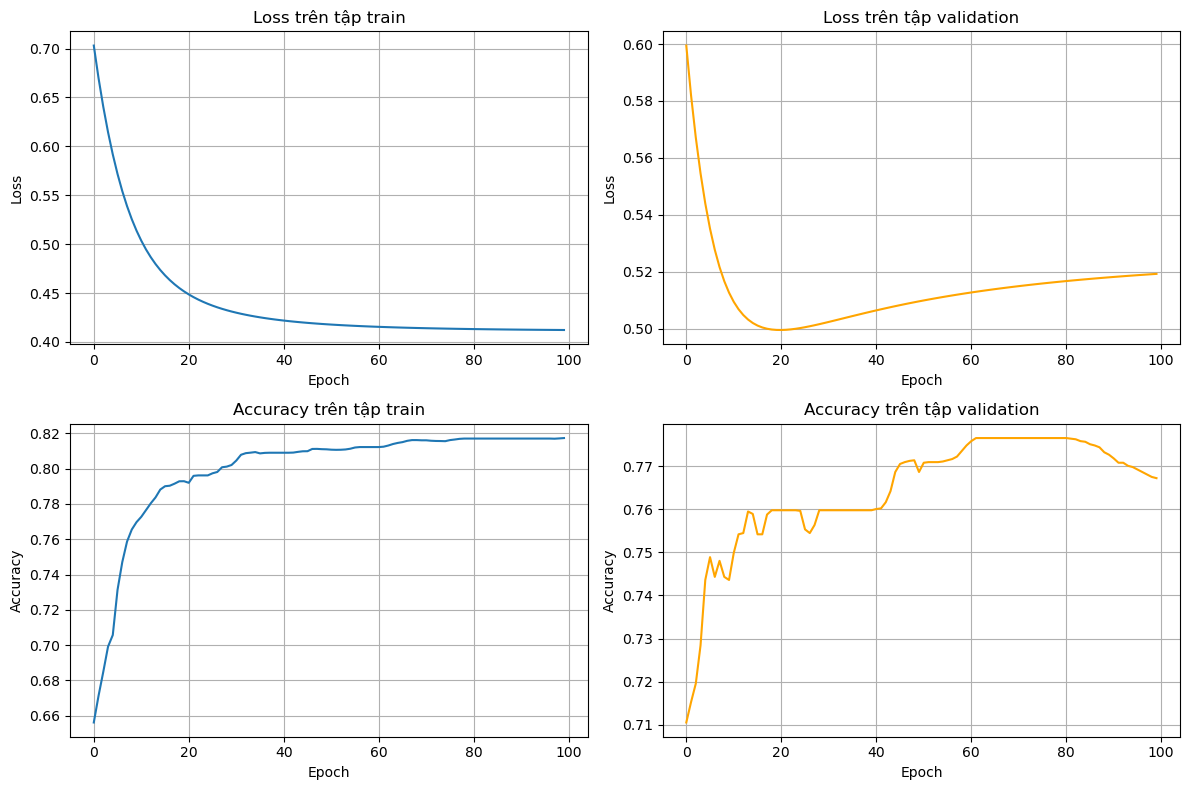

In [105]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0, 0].plot(train_losses)
ax[0, 0].set(xlabel="Epoch", ylabel="Loss")
ax[0, 0].set_title("Loss trên tập train")

ax[0, 1].plot(val_losses, color="orange")
ax[0, 1].set(xlabel="Epoch", ylabel="Loss")
ax[0, 1].set_title("Loss trên tập validation")

ax[1, 0].plot(train_accs)
ax[1, 0].set(xlabel="Epoch", ylabel="Accuracy")
ax[1, 0].set_title("Accuracy trên tập train")

ax[1, 1].plot(val_accs, color="orange")
ax[1, 1].set(xlabel="Epoch", ylabel="Accuracy")
ax[1, 1].set_title("Accuracy trên tập validation")

for a in ax.flat:
    a.grid(True)

plt.tight_layout()
plt.show()

- **Loss trên tập train** giảm đều từ 0.703 xuống 0.412 và gần như ngang từ epoch 40 trở đi.
- **Loss trên tập validation** giảm từ 0.599 xuống thấp nhất khoảng 0.488 quanh epoch 20, sau đó tăng dần lên 0.519 ở epoch 100. Đây là dấu hiệu của overfiting nhẹ, khi mô hình bắt đầu khớp với các chi tiết riêng của tập train mà không cnò tổng quát thêm được cho dữ liệu mới.
- **Accuracy** trên ập train tăng tới 0.817, còn trên tập validation dừng quanh 0.767. Khoảng này nhỏ nên mức overfiting ở đây chưa nghiêm trọng.

Vì vậy có thể dừng huấn luyện ở epoch 20 để lấy mô hình có loss validation thấp nhất.

In [106]:
val_set_acc = compute_accuracy(X_val, y_val, theta)
test_set_acc = compute_accuracy(X_test, y_test, theta)

print("Evaluation on validation set:")
print(f"Accuracy: {val_set_acc}")
print("Evaluation on test set:")
print(f"Accuracy: {test_set_acc}")

Evaluation on validation set:
Accuracy: 0.770949720670391
Evaluation on test set:
Accuracy: 0.7752808988764045
